# White Hat / Black Hat: Country Recovery Fairness

This notebook focuses on the country-level ethics pair used in the final webpage. Both visualizations use the same state-level emissions dataset and the same 2019-to-2024 comparison. The white-hat version asks whether each country's CO₂ recovery was proportional to its traffic recovery. The black-hat version demonstrates how the same data can be narrowed to percent flight growth only, creating a cleaner but incomplete recovery narrative.


## 1. Setup


In [11]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd

In [12]:
def find_project_root(start=Path.cwd()):
    for path in (start, *start.parents):
        if (path / "pyproject.toml").exists() and (path / "data").exists():
            return path
    raise RuntimeError("Could not find project root")


PROJECT_ROOT = find_project_root()
CLEAN_DIR = PROJECT_ROOT / "data" / "clean"
FIGURE_DIR = PROJECT_ROOT / "figures"
FIGURE_DIR.mkdir(exist_ok=True)


def save_figure(fig, name: str) -> None:
    fig.savefig(FIGURE_DIR / f"{name}.png", dpi=200, bbox_inches="tight")
    fig.savefig(FIGURE_DIR / f"{name}.pdf", bbox_inches="tight")

In [13]:
# palette from european_aviation_final.html design tokens
BLUE  = "#537D96"
RED   = "#BF4646"
DARK  = "#2C2F33"
MUTED = "#72777C"
LINE  = "#E3E6E8"

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
    "axes.edgecolor":   LINE,
    "axes.linewidth":   0.8,
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "axes.labelcolor":  DARK,
    "axes.labelsize":   9,
    "axes.labelpad":    8,
    "axes.titlesize":   14,
    "axes.titleweight": "bold",
    "axes.titlecolor":  DARK,
    "axes.titlepad":    12,
    "xtick.color":      MUTED,
    "xtick.labelsize":  9,
    "ytick.color":      MUTED,
    "ytick.labelsize":  9,
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "font.family":      "sans-serif",
    "figure.dpi":       130,
})


## 2. Data


In [14]:
df_state = pd.read_csv(CLEAN_DIR / "emission_state_clean.csv", parse_dates=["DATE"])

CODE2NAME = {
    "AL": "Albania", "AM": "Armenia", "AT": "Austria", "AZ": "Azerbaijan",
    "BA": "Bosnia", "BE": "Belgium", "BG": "Bulgaria", "CH": "Switzerland",
    "CY": "Cyprus", "CZ": "Czechia", "DE": "Germany", "DK": "Denmark",
    "EE": "Estonia", "ES": "Spain", "FI": "Finland", "FR": "France",
    "GB": "UK", "GE": "Georgia", "GR": "Greece", "HR": "Croatia",
    "HU": "Hungary", "IE": "Ireland", "IL": "Israel", "IS": "Iceland",
    "IT": "Italy", "LT": "Lithuania", "LU": "Luxembourg", "LV": "Latvia",
    "MA": "Morocco", "MD": "Moldova", "ME": "Montenegro", "MK": "Macedonia",
    "MT": "Malta", "NL": "Netherlands", "NO": "Norway", "PL": "Poland",
    "PT - Lisbon FIR": "Portugal", "PT - Santa Maria FIR": "PT Azores",
    "RO": "Romania", "RS": "Serbia", "SE": "Sweden", "SI": "Slovenia",
    "SK": "Slovakia", "TR": "Turkey", "UA": "Ukraine",
}


## 3. Country Recovery Fairness

The central project question is whether European aviation recovered sustainably after COVID-19. At country level, this is not just a question of which markets grew fastest. A fair comparison must ask two things at the same time: how much traffic came back, and whether CO₂ came back faster than traffic.

The white-hat visualization uses a two-dimensional benchmark. Each country is positioned by its 2024 flight recovery on the x-axis and its 2024 CO₂ recovery on the y-axis, both indexed to 2019. The diagonal reference line marks proportional recovery: countries above it have an emissions penalty because CO₂ rose more than traffic; countries below it recovered traffic with a lower CO₂ rebound. Bubble size adds the missing scale context by encoding absolute 2024 CO₂.

The black-hat visualization intentionally removes that context. It ranks countries only by percent flight growth above 2019. This can make small or unusual markets look like the main recovery story while hiding whether emissions grew faster than traffic and how much CO₂ each country actually contributed.


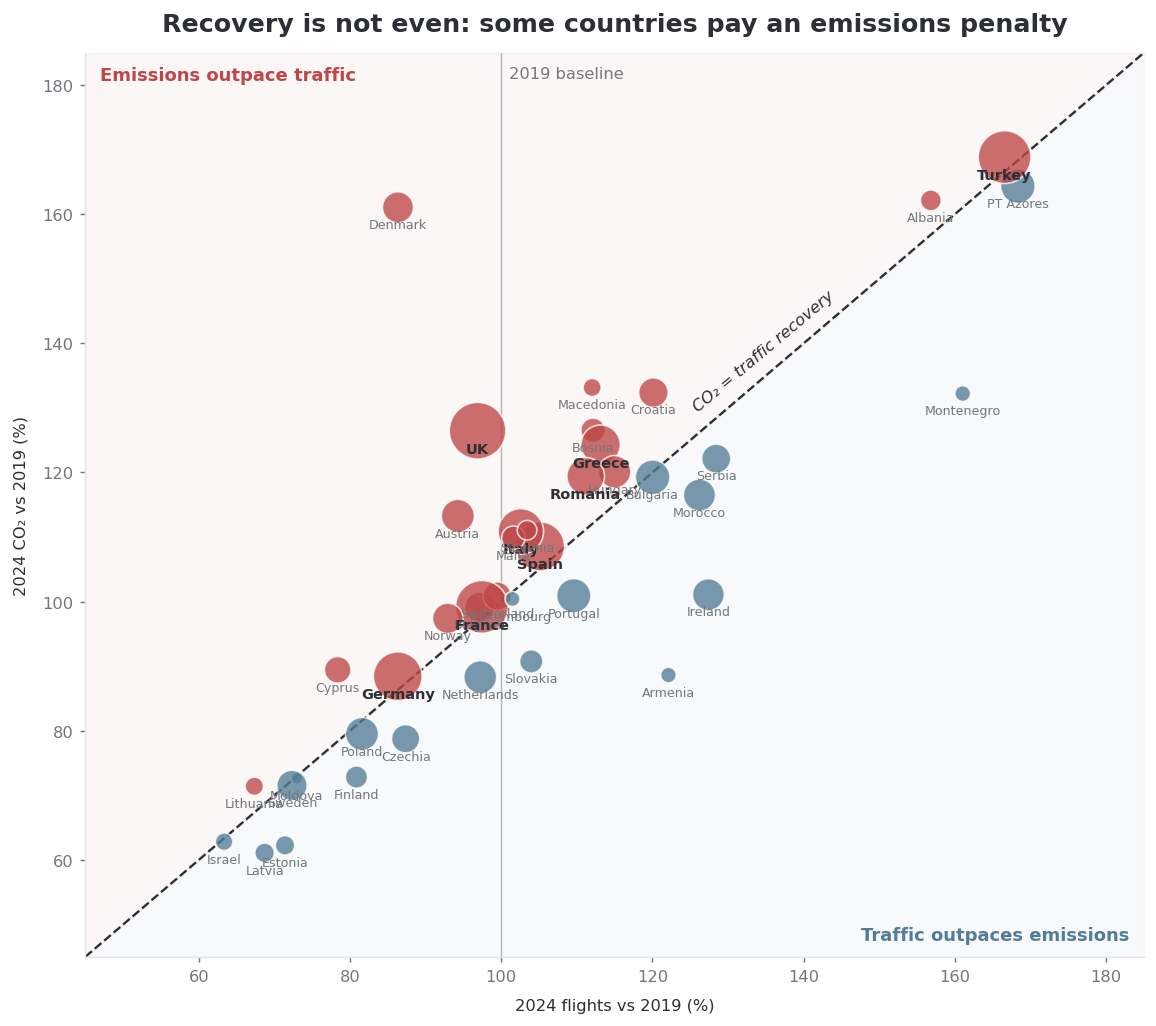

In [15]:
state_year = (
    df_state.groupby(["AREA", "YEAR"])
    .agg(flights=("NB_FLIGHTS", "sum"), co2=("CO2_KG", "sum"))
    .reset_index()
)
wide = (
    state_year[state_year["YEAR"].isin([2019, 2024])]
    .pivot(index="AREA", columns="YEAR", values=["flights", "co2"])
    .dropna()
)
state_piv = pd.DataFrame({
    "AREA":        wide.index.astype(str),
    "flight_idx":  wide["flights"][2024] / wide["flights"][2019] * 100,
    "co2_idx":     wide["co2"][2024]     / wide["co2"][2019]     * 100,
    "co2_2024_mt": wide["co2"][2024] / 1e9,
})
state_piv["gap"]  = state_piv["co2_idx"] - state_piv["flight_idx"]
state_piv["name"] = state_piv["AREA"].map(CODE2NAME).fillna(state_piv["AREA"])

ps = state_piv[(state_piv["flight_idx"].between(45, 185)) &
               (state_piv["co2_idx"].between(45, 185))].copy()

fig, ax = plt.subplots(figsize=(9, 8))

LIM = (45, 185)
ax.set_xlim(*LIM)
ax.set_ylim(*LIM)

ax.fill_between([LIM[0], LIM[1]], [LIM[0], LIM[1]], LIM[1],
                color=RED, alpha=0.04, zorder=0)
ax.fill_between([LIM[0], LIM[1]], LIM[0], [LIM[0], LIM[1]],
                color=BLUE, alpha=0.04, zorder=0)

ax.axvline(100, color=MUTED, lw=0.8, alpha=0.5, zorder=1)
ax.text(101, 183, "2019 baseline", color=MUTED, fontsize=9, va="top")

ax.plot(LIM, LIM, color=DARK, ls="--", lw=1.3, zorder=2)
ax.text(125, 129, "CO₂ = traffic recovery",
        color=DARK, fontsize=9, fontstyle="italic", rotation=40, va="bottom")

ax.text(47, 183, "Emissions outpace traffic",
        color=RED, fontsize=10, fontweight="bold", va="top")
ax.text(183, 47, "Traffic outpaces emissions",
        color=BLUE, fontsize=10, fontweight="bold", ha="right", va="bottom")

colors = np.where(ps["gap"] >= 0, RED, BLUE)
sizes  = (ps["co2_2024_mt"].clip(lower=0.05) ** 0.55) * 160
sc = ax.scatter(ps["flight_idx"], ps["co2_idx"],
                s=sizes, c=colors, alpha=0.78,
                edgecolors="white", linewidths=0.9, zorder=3)

top8 = set(ps.nlargest(8, "co2_2024_mt")["name"])
for _, r in ps.iterrows():
    bold = r["name"] in top8
    ax.annotate(r["name"], (r["flight_idx"], r["co2_idx"]),
                xytext=(0, -6), textcoords="offset points",
                ha="center", va="top",
                fontsize=8 if bold else 7,
                color=DARK if bold else MUTED,
                fontweight="bold" if bold else "normal")

ax.set_xlabel("2024 flights vs 2019 (%)")
ax.set_ylabel("2024 CO₂ vs 2019 (%)")
ax.set_title(
    "Recovery is not even: some countries pay an emissions penalty",
)

fig.tight_layout()
save_figure(fig, "whitehat_country_recovery_gap_scatter")
plt.show()

## 4. CO2 per flight over time: truthful and misleading scales

Both plots use the same yearly data: total CO2 divided by total flights for each year from 2019 to 2024. The truthful chart uses a zero baseline. The misleading chart keeps the same values but compresses the vertical scale, making the moderate increase look dramatic.

In [16]:
BAR_BLUE = "#2C3947"

yearly_efficiency = (
    df_state.groupby("YEAR", as_index=False)
    .agg(co2_kg=("CO2_KG", "sum"), flights=("NB_FLIGHTS", "sum"))
)
yearly_efficiency["co2_kg_per_flight"] = yearly_efficiency["co2_kg"] / yearly_efficiency["flights"]
yearly_efficiency = yearly_efficiency.sort_values("YEAR")

yearly_efficiency[["YEAR", "co2_kg_per_flight"]]


,YEAR,co2_kg_per_flight
0,2019,1433.755979
1,2020,1539.757213
2,2021,1558.670224
3,2022,1532.473867
4,2023,1569.570941
5,2024,1612.588657


In [17]:
eff_max = yearly_efficiency["co2_kg_per_flight"].max()
eff_min = yearly_efficiency["co2_kg_per_flight"].min()
eff_truncate_at = 1400.0

eff_data_effect = (eff_max - eff_min) / eff_min
eff_white_lie_factor = 1.0
eff_black_graphic_effect = (eff_max - eff_min) / (eff_min - eff_truncate_at)
eff_black_lie_factor = eff_black_graphic_effect / eff_data_effect
actual_eff_ratio = eff_max / eff_min
visible_eff_ratio = (eff_max - eff_truncate_at) / (eff_min - eff_truncate_at)

print(f"Actual comparison: {eff_max:.0f} vs {eff_min:.0f} kg CO2 per flight")
print(f"Actual ratio: {actual_eff_ratio:.2f}x")
print(f"White-hat lie factor: {eff_white_lie_factor:.2f}")
print(f"Black-hat visible ratio after scale compression: {visible_eff_ratio:.2f}x")
print(f"Black-hat lie factor: {eff_black_lie_factor:.2f}")


Actual comparison: 1613 vs 1434 kg CO2 per flight
Actual ratio: 1.12x
White-hat lie factor: 1.00
Black-hat visible ratio after scale compression: 6.30x
Black-hat lie factor: 42.47


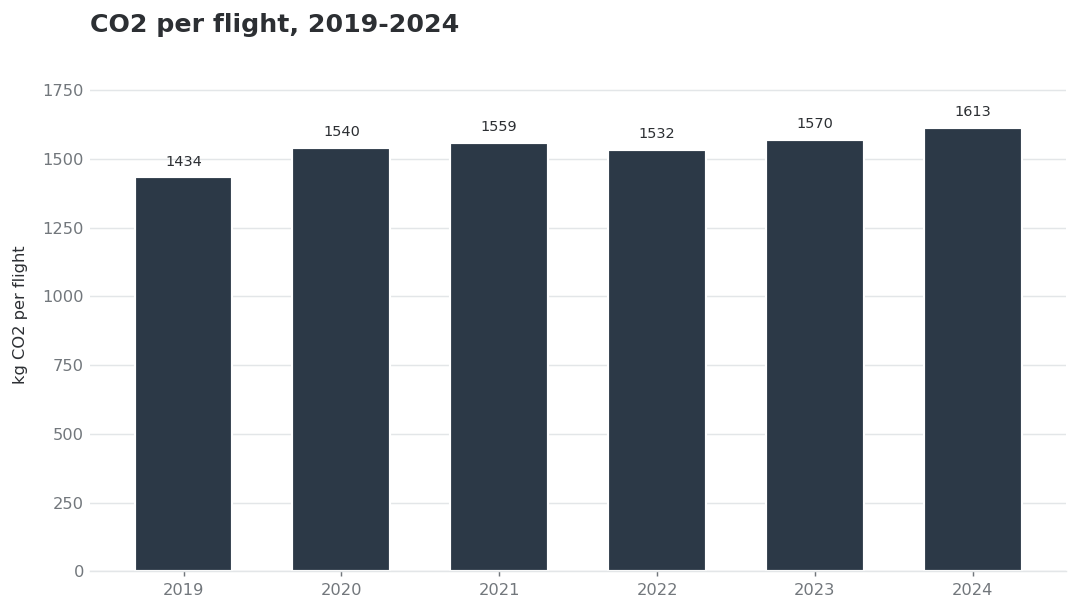

In [18]:
fig, ax = plt.subplots(figsize=(8.4, 4.8))
bars = ax.bar(
    yearly_efficiency["YEAR"].astype(str),
    yearly_efficiency["co2_kg_per_flight"],
    color=BAR_BLUE,
    edgecolor="white",
    linewidth=1.2,
    width=0.62,
)
ax.set_ylim(0, eff_max * 1.16)
ax.set_ylabel("kg CO2 per flight")
ax.set_title("CO2 per flight, 2019-2024", loc="left", pad=14)
ax.grid(axis="y", color=LINE, linewidth=0.8)
ax.set_axisbelow(True)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_color(LINE)
ax.tick_params(axis="y", length=0)

for bar, val in zip(bars, yearly_efficiency["co2_kg_per_flight"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        val + 32,
        f"{val:.0f}",
        ha="center",
        va="bottom",
        fontsize=8,
        color=DARK,
    )
'''
ax.text(
    0.01,
    -0.18,
    f"Lie factor = graphic effect / data effect = {eff_data_effect:.2f} / {eff_data_effect:.2f} = {eff_white_lie_factor:.2f}",
    transform=ax.transAxes,
    fontsize=8,
    color=MUTED,
)
'''
plt.tight_layout()
save_figure(fig, "whitehat_yearly_co2_per_flight")
plt.show()


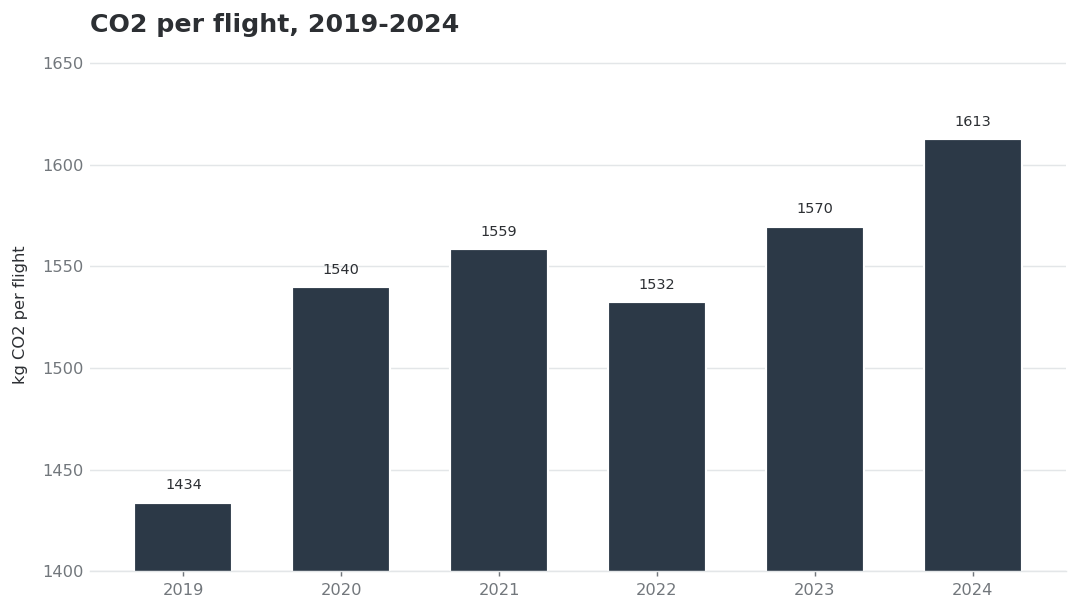

In [19]:
fig, ax = plt.subplots(figsize=(8.4, 4.8))
bars = ax.bar(
    yearly_efficiency["YEAR"].astype(str),
    yearly_efficiency["co2_kg_per_flight"],
    color=BAR_BLUE,
    edgecolor="white",
    linewidth=1.2,
    width=0.62,
)
ax.set_ylim(eff_truncate_at, eff_max * 1.025)
ax.set_ylabel("kg CO2 per flight")
ax.set_title("CO2 per flight, 2019-2024", loc="left", pad=14)
ax.grid(axis="y", color=LINE, linewidth=0.8)
ax.set_axisbelow(True)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_color(LINE)
ax.tick_params(axis="y", length=0)

for bar, val in zip(bars, yearly_efficiency["co2_kg_per_flight"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        val + 5,
        f"{val:.0f}",
        ha="center",
        va="bottom",
        fontsize=8,
        color=DARK,
    )
'''
ax.text(
    0.01,
    -0.18,
    f"Lie factor = graphic effect / data effect = {eff_black_graphic_effect:.2f} / {eff_data_effect:.2f} = {eff_black_lie_factor:.2f}",
    transform=ax.transAxes,
    fontsize=8,
    color=MUTED,
)
'''
plt.tight_layout()
save_figure(fig, "blackhat_yearly_co2_per_flight_truncated_axis")
plt.show()


**Comment.** The two plots use exactly the same data: yearly total CO2 divided by yearly total flights. The truthful chart shows the increase from 2019 to 2024 as real but moderate: about 1,434 kg CO2 per flight to about 1,613 kg CO2 per flight, or roughly 1.12x.

The misleading chart compresses the vertical scale by starting it at 1,400 kg. No data points are removed and no values are changed, but the visual distance is inflated. The data effect is `(1612.59 - 1433.76) / 1433.76 = 0.12`. The graphic effect after truncation is `(1612.59 - 1433.76) / (1433.76 - 1400.00) = 5.30`. Therefore the lie factor is `5.30 / 0.12 = 42.47`.